# EDA1 — Distributions & Data Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# ---- shared config (identical in EDA1 and EDA2) ----
DATA_PATH = "../data/processed/dataset_labelled_with_score.csv"

FEATURES = [
    "bank_count_500m", "bus_stop_count_500m", "cinema_count_500m",
    "clinic_count_500m", "college_count_500m", "hospital_count_500m",
    "museum_count_500m", "office_count_500m", "parking_space_count_500m",
    "recreation_count_500m", "retail_count_500m", "school_count_500m",
    "temple_count_500m", "competitor_count_500m", "avg_restaurant_rating_500m",
    "avg_review_ratings_500m", "nearest_restaurant_m",
]
TARGET = "feasibility_label"     # Low / Moderate / High
PRESENCE = "label"               # 1 = real restaurant, 0 = background
TIER_ORDER = ["Low", "Moderate", "High"]

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.head()

shape: (4172, 61)


,place_id,latitude,longitude,search_area,primary_type,searched_as,label,feasibility_score,feasibility_label,cluster,bank_count_500m,bank_count_500m_normalized,bank_count_500m_contribution,bus_stop_count_500m,bus_stop_count_500m_normalized,bus_stop_count_500m_contribution,cinema_count_500m,cinema_count_500m_normalized,cinema_count_500m_contribution,clinic_count_500m,clinic_count_500m_normalized,clinic_count_500m_contribution,college_count_500m,college_count_500m_normalized,college_count_500m_contribution,hospital_count_500m,hospital_count_500m_normalized,hospital_count_500m_contribution,museum_count_500m,museum_count_500m_normalized,museum_count_500m_contribution,office_count_500m,office_count_500m_normalized,office_count_500m_contribution,parking_space_count_500m,parking_space_count_500m_normalized,parking_space_count_500m_contribution,recreation_count_500m,recreation_count_500m_normalized,recreation_count_500m_contribution,retail_count_500m,retail_count_500m_normalized,retail_count_500m_contribution,school_count_500m,school_count_500m_normalized,school_count_500m_contribution,temple_count_500m,temple_count_500m_normalized,temple_count_500m_contribution,nearest_restaurant_m,nearest_restaurant_m_normalized,nearest_restaurant_m_contribution,competitor_count_500m,competitor_count_500m_normalized,competitor_count_500m_contribution,avg_restaurant_rating_500m,avg_restaurant_rating_500m_normalized,avg_restaurant_rating_500m_contribution,avg_review_ratings_500m,avg_review_ratings_500m_normalized,avg_review_ratings_500m_contribution
0,ChIJsZ5mY70Z6zkRRBczgL9a8ms,27.699546,85.337687,Baneshwor,restaurant,restaurant,1,18.652333,Moderate,0,26,0.273684,0.018875,1,0.090909,0.007885,0,0.000000,0.000000,44,0.578947,0.026628,22,0.343750,0.023808,9,0.290323,0.012063,1,0.027778,0.00446,54,0.524272,0.022053,5,0.217391,0.016110,21,0.272727,0.009656,52,0.329114,0.007984,35,0.583333,0.017102,15,0.144231,0.010072,66.357920,0.015377,0.000851,20,0.837398,0.006476,4.265000,0.183750,0.002125,87.700000,0.941020,0.000377
1,ChIJ5SO0EQ0Z6zkRTMnqUebrTqA,27.692262,85.336472,Baneshwor,restaurant,restaurant,1,27.954012,High,2,43,0.452632,0.031216,4,0.363636,0.031538,1,0.142857,0.025274,46,0.605263,0.027838,37,0.578125,0.040041,13,0.419355,0.017424,1,0.027778,0.00446,66,0.640777,0.026953,6,0.260870,0.019332,16,0.207792,0.007357,80,0.506329,0.012284,40,0.666667,0.019545,13,0.125000,0.008729,3.883478,0.000900,0.000050,44,0.642276,0.004967,4.247727,0.188068,0.002175,159.477273,0.892192,0.000357
2,ChIJTdMmLgAZ6zkR84zXOWwdgPE,27.689064,85.334295,Baneshwor,restaurant,restaurant,1,37.665885,High,2,57,0.600000,0.041379,6,0.545455,0.047307,3,0.428571,0.075822,65,0.855263,0.039336,49,0.765625,0.053028,12,0.387097,0.016084,1,0.027778,0.00446,68,0.660194,0.027770,9,0.391304,0.028998,15,0.194805,0.006897,66,0.417722,0.010134,28,0.466667,0.013681,6,0.057692,0.004029,35.022157,0.008116,0.000449,48,0.609756,0.004716,4.231250,0.192187,0.002222,201.104167,0.863875,0.000346
3,ChIJ3Ru72S8Z6zkR6JYG3tsYlGk,27.681549,85.341340,Baneshwor,restaurant,restaurant,1,12.152369,Low,1,5,0.052632,0.003630,0,0.000000,0.000000,0,0.000000,0.000000,23,0.302632,0.013919,6,0.093750,0.006493,4,0.129032,0.005361,0,0.000000,0.00000,66,0.640777,0.026953,4,0.173913,0.012888,26,0.337662,0.011955,78,0.493671,0.011976,16,0.266667,0.007818,17,0.163462,0.011414,5.217717,0.001209,0.000067,14,0.886179,0.006854,4.371429,0.157143,0.001817,83.214286,0.944072,0.000378
4,ChIJJbL_SlQZ6zkRFWSjunPmuVU,27.688812,85.334080,Baneshwor,restaurant,restaurant,1,37.304810,High,2,55,0.578947,0.039927,6,0.545455,0.047307,3,0.428571,0.075822,66,0.868421,0.039942,46,0.718750,0.049781,11,0.354839,0.014744,1,0.027778,0.00446,65,0.631068,0.026545,10,0.434783,0.032220,15,0.194805,0.006897,64,0.405063,0.009827,27,0.450000,0.013193,7,0.067308,0.004700,35.022157,0.008116,0.000449,47,0.617886,0.004779,4.270213,0.182447,0.002110,200.893617,0.864018,0.000346


# Target distribution

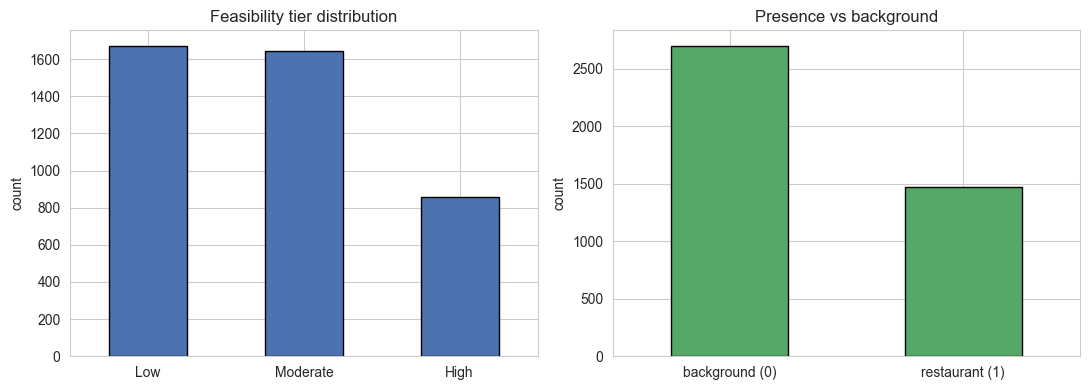

feasibility_label (%):
feasibility_label
Low         40.1
Moderate    39.4
High        20.5
Name: proportion, dtype: float64

label (%):
label
0    64.7
1    35.3
Name: proportion, dtype: float64


In [2]:
# 8. Target distribution -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df[TARGET].value_counts().reindex(TIER_ORDER).plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="black")
axes[0].set_title("Feasibility tier distribution")
axes[0].set_xlabel(""); axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

df[PRESENCE].map({1: "restaurant (1)", 0: "background (0)"}).value_counts().plot(
    kind="bar", ax=axes[1], color="#55A868", edgecolor="black")
axes[1].set_title("Presence vs background")
axes[1].set_xlabel(""); axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

print("feasibility_label (%):")
print((df[TARGET].value_counts(normalize=True).reindex(TIER_ORDER) * 100).round(1))
print("\nlabel (%):")
print((df[PRESENCE].value_counts(normalize=True) * 100).round(1))

## Interpretation of Feasibility Tier Distribution

The feasibility tier distribution shows that approximately **40%** of locations are classified as **Low**, **39%** as **Moderate**, and **20%** as **High** feasibility.

### Key Observations

- **High-feasibility locations are the minority (20%)**, indicating that highly suitable restaurant locations are relatively scarce.

- The feasibility tiers are generated using **K-Means clustering on the feasibility score**, so they represent the distribution of the scoring model rather than an independent fact about Kathmandu Valley.

### Modeling Implications

- Since the **High** class is the smallest, **accuracy alone can be misleading**. Therefore, **Macro-F1 Score** and **Per-Class Recall** should be used to evaluate model performance.

---

## Interpretation of Presence vs. Background Distribution

The dataset consists of approximately **65% background locations** and **35% existing restaurant locations**.

### Key Observations

- This ratio is **a result of the sampling strategy** (2,700 background points and 1,472 restaurants), not a real-world distribution of land use.

### Modeling Implications

- The class imbalance should be handled using:

```python
class_weight="balanced"
```

when training the Random Forest classifier.

---

## Relationship Between Presence and Feasibility

- **Presence** indicates whether a restaurant currently exists at a location, while **feasibility** estimates how suitable that location is for opening a restaurant.

- Background (empty) locations also receive feasibility scores, enabling the system to evaluate potential business sites.

- Existing restaurants appear in **High-feasibility areas more often than background locations**, but the relationship is **positive yet relatively weak**, suggesting the feasibility score captures some meaningful patterns but is not a strong predictor of restaurant presence.

---

## Limitation

The **Low**, **Moderate**, and **High** feasibility tiers are generated from the **Entropy Weight Method and K-Means clustering**. Therefore, they should be interpreted as the output of the scoring methodology rather than an objective representation of restaurant feasibility across Kathmandu Valley.

# Descriptive statistics

In [3]:
# 9. Descriptive statistics (17 raw features only) -----------------------
desc = df[FEATURES].describe().T
desc["skew"] = df[FEATURES].skew()
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew"]]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
bank_count_500m,4172.0,18.59,18.57,0.0,4.00,14.00,26.00,95.00,1.33
bus_stop_count_500m,4172.0,2.08,2.22,0.0,0.00,1.00,3.00,11.00,1.13
cinema_count_500m,4172.0,0.61,1.03,0.0,0.00,0.00,1.00,7.00,1.86
clinic_count_500m,4172.0,21.13,16.24,0.0,8.00,19.00,32.00,76.00,0.75
college_count_500m,4172.0,11.33,11.52,0.0,3.00,8.00,16.00,64.00,1.47
hospital_count_500m,4172.0,7.38,5.44,0.0,3.00,7.00,10.00,31.00,0.98
museum_count_500m,4172.0,3.59,6.56,0.0,0.00,1.00,4.00,36.00,2.72
office_count_500m,4172.0,37.96,26.94,0.0,13.00,35.00,62.00,103.00,0.24
parking_space_count_500m,4172.0,4.41,4.60,0.0,1.00,3.00,6.00,23.00,1.42
recreation_count_500m,4172.0,15.65,11.65,0.0,9.00,14.00,20.00,77.00,2.31


## Interpretation of Descriptive Statistics

The descriptive statistics reveal the distribution and variability of the features used in the feasibility analysis.

### Key Observations

- **nearest_restaurant_m** has the highest skewness (**8.11**), indicating that most locations are close to a restaurant, while a few locations are highly isolated.

- Other highly right-skewed features include **museum (2.72)**, **recreation (2.31)**, **avg_review_ratings (2.13)**, **temple (1.97)**, and **cinema (1.86)**. These features are absent in most locations but concentrated in a few areas.

- Features such as **retail (0.15)**, **office (0.24)**, and **school (0.41)** have relatively low skewness, indicating a more even distribution across the study area.

### Mean vs. Median

For features like **museum** and **cinema**, the mean is much higher than the median, showing the presence of a few extreme values. This explains why the **Entropy Weight Method** assigned them high weights, as it favours features with greater variation rather than business importance.

### Data Quality

All POI count features have a minimum value of **0**, which is expected. However, the minimum value of **1.0** for the average rating features is likely due to missing-value imputation rather than actual one-star restaurant clusters.

### Modeling Implications

The features have very different scales and several are highly skewed. While scaling would be necessary for distance-based algorithms, it is **not required for Random Forest**, though the skewed distributions should be documented.

# Important-feature distributions.

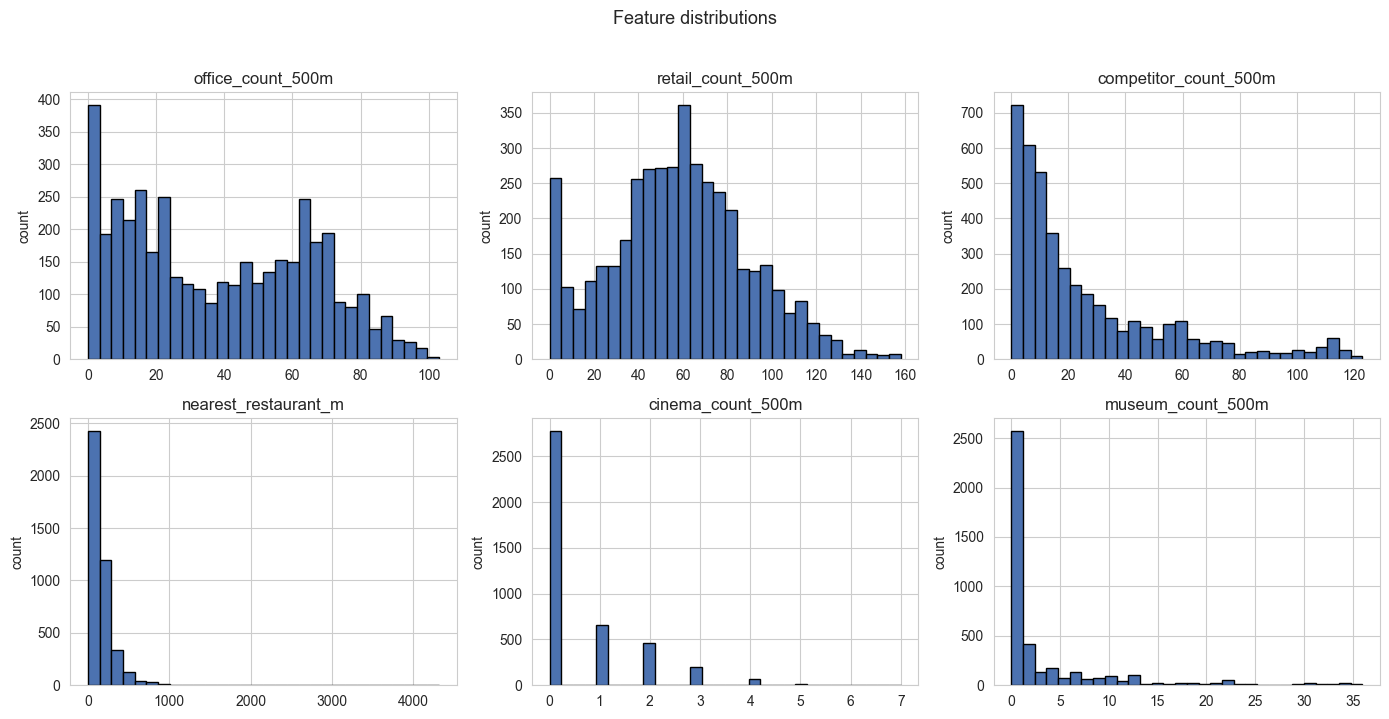

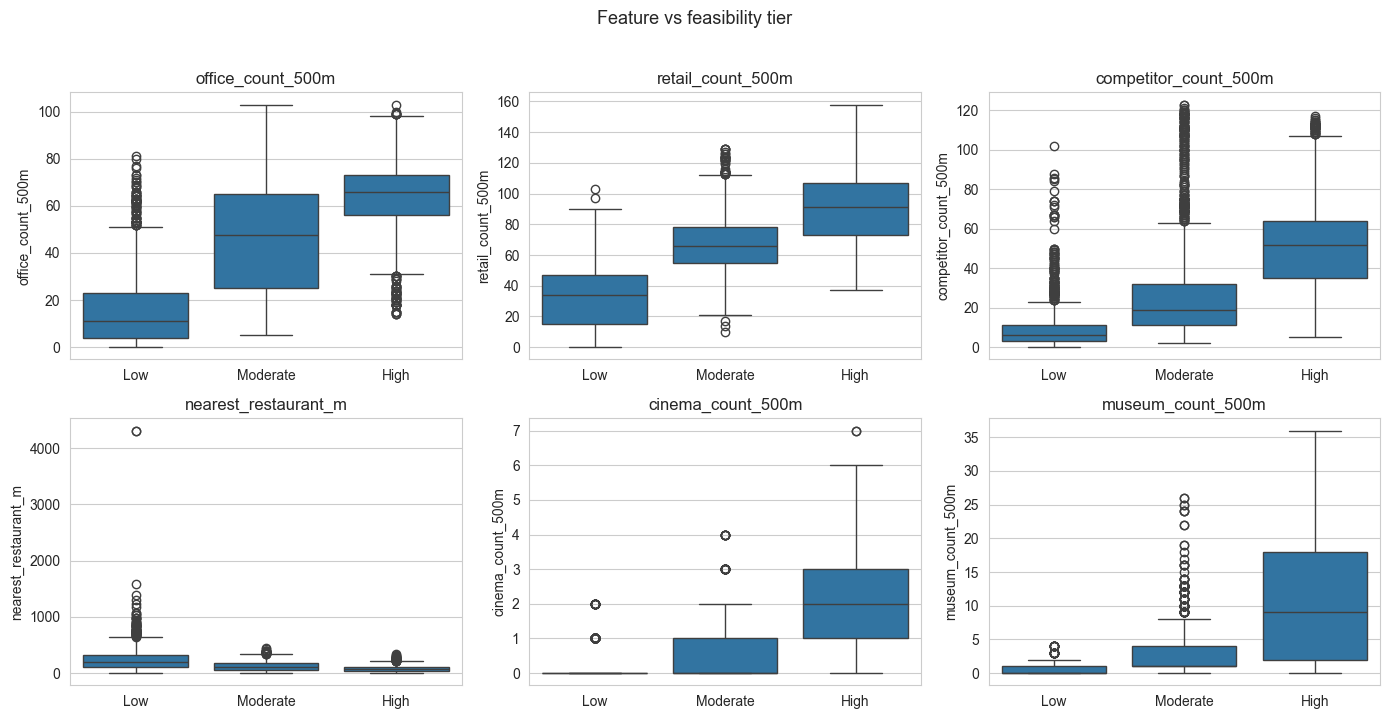

In [4]:
# 11. Important-feature distributions ------------------------------------
key_feats = ["office_count_500m", "retail_count_500m", "competitor_count_500m",
             "nearest_restaurant_m", "cinema_count_500m", "museum_count_500m"]

# --- histograms (overall shape) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_feats):
    ax.hist(df[col], bins=30, color="#4C72B0", edgecolor="black")
    ax.set_title(col); ax.set_ylabel("count")
fig.suptitle("Feature distributions", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# --- boxplots split by feasibility tier (separation) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_feats):
    sns.boxplot(data=df, x=TARGET, y=col, order=TIER_ORDER, ax=ax)
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Feature vs feasibility tier", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## Interpretation of Feature Distributions

The histograms illustrate the distribution of the features and highlight differences in their variability and usefulness for modelling.

### Key Observations

- **Retail** and **office** show relatively balanced distributions with values spread across a wide range, indicating that they contain useful information for distinguishing locations.

- **Competitor count** and **nearest_restaurant_m** are strongly right-skewed. Most locations have few nearby competitors or are close to an existing restaurant, while only a small number of locations have very high values or are highly isolated.

- **Cinema** and **museum** contain mostly zero values, meaning these facilities are absent from most locations. Their distributions show very little variation across the dataset.

### Implications

- The strong right-skew observed in several features should be documented. Feature transformation (e.g., logarithmic transformation) is only necessary if scale-sensitive models are used, and is not required for Random Forest.

- The sparse distributions of **cinema** and **museum** explain why the **Entropy Weight Method** assigned them high weights. Entropy rewards variation rather than business importance, making these features candidates for removal or grouping during feature selection.

- **Retail** and **office** appear to be the most informative features because they vary consistently across locations and are likely to contribute more meaningful information to the prediction model.

# Outlier check

                   feature  outliers  pct    max
         museum_count_500m       451 10.8   36.0
         temple_count_500m       437 10.5  104.0
         cinema_count_500m       284  6.8    7.0
     competitor_count_500m       265  6.4  123.0
  parking_space_count_500m       261  6.3   23.0
        college_count_500m       224  5.4   64.0
      nearest_restaurant_m       223  5.3 4315.3
     recreation_count_500m       171  4.1   77.0
avg_restaurant_rating_500m       169  4.1    5.0
           bank_count_500m       150  3.6   95.0
       hospital_count_500m       109  2.6   31.0
       bus_stop_count_500m        86  2.1   11.0
         retail_count_500m        27  0.6  158.0
   avg_review_ratings_500m        27  0.6 1471.0
         school_count_500m        25  0.6   60.0
         clinic_count_500m        24  0.6   76.0
         office_count_500m         0  0.0  103.0


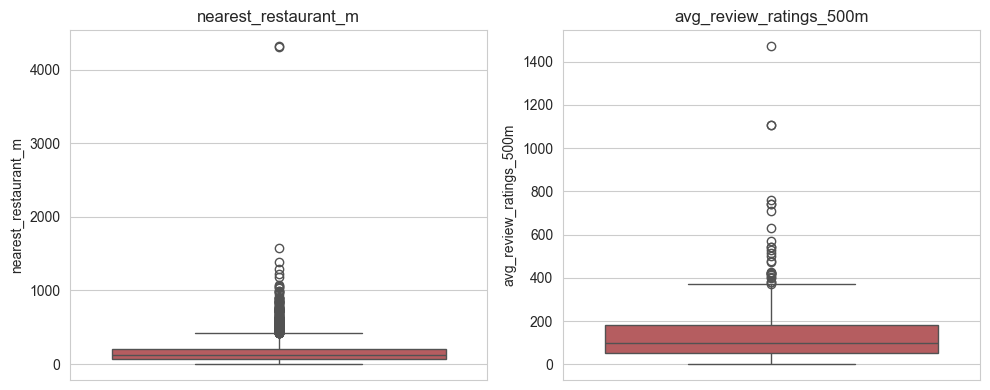

In [5]:
# 14. Outlier check (IQR rule) -------------------------------------------
rows = []
for col in FEATURES:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    rows.append({"feature": col, "outliers": int(n_out),
                 "pct": round(100 * n_out / len(df), 1),
                 "max": round(df[col].max(), 1)})

outlier_summary = pd.DataFrame(rows).sort_values("outliers", ascending=False)
print(outlier_summary.to_string(index=False))

# visual on the two widest-range features
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["nearest_restaurant_m"], ax=axes[0], color="#C44E52")
axes[0].set_title("nearest_restaurant_m")
sns.boxplot(y=df["avg_review_ratings_500m"], ax=axes[1], color="#C44E52")
axes[1].set_title("avg_review_ratings_500m")
plt.tight_layout(); plt.show()

## Interpretation of Boxplots

The boxplots highlight the presence of outliers and the spread of key features in the dataset.

### Key Observations

- **nearest_restaurant_m** contains the most extreme outliers, with a few highly isolated locations far from existing restaurants. This confirms its strong right-skewed distribution.

- **avg_review_ratings_500m** also shows a few extreme values, representing locations near very popular restaurants with exceptionally high review counts.

- Features such as **museum**, **temple**, and **cinema** show several outliers because they are sparse—most locations have zero values while a few contain high counts. These represent genuine characteristics of the data rather than errors.

- **Office** shows no significant outliers, indicating a stable and well-distributed feature.

### Implications

- The detected outliers are **valid observations**, reflecting real geographic and business conditions rather than data quality issues.

- Since the primary prediction model is **Random Forest**, these outliers are retained because tree-based models are robust to extreme values. However, highly skewed features such as **nearest_restaurant_m** and **avg_review_ratings_500m** may require logarithmic transformation if scale-sensitive algorithms are used in future work.

# Missing-value confirmation (post-scoring)

In [6]:
# 15. Missing values (post-scoring) --------------------------------------
miss = df[FEATURES].isnull().sum()
miss = miss[miss > 0]

if len(miss) == 0:
    print("No missing values in the 17 features.")
    print("Note: avg_restaurant_rating_500m / avg_review_ratings_500m originally had")
    print("40 NaNs (restaurants with no neighbor within 500m). These were median-filled")
    print("during entropy scoring, so the modeling dataset is complete.")
else:
    print("Missing values found:")
    print(miss)

No missing values in the 17 features.
Note: avg_restaurant_rating_500m / avg_review_ratings_500m originally had
40 NaNs (restaurants with no neighbor within 500m). These were median-filled
during entropy scoring, so the modeling dataset is complete.
